# Partial Cross Entropy Loss for Weakly Supervised Segmentation (TensorFlow)

## Problem Statement
In many remote sensing applications, obtaining full pixel-level annotations is expensive and time-consuming. Point annotations provide a more practical alternative, but standard deep learning losses require complete segmentation masks.

## Solution Overview
This notebook implements:
1. **Partial Cross Entropy Loss** - A modified loss that only computes loss on labeled pixels
2. **Point Label Simulation** - Converting full masks to sparse point annotations
3. **Experiments** - Exploring factors affecting performance

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, optimizers, losses
import matplotlib.pyplot as plt
from PIL import Image
import random
from tqdm import tqdm
from scipy.ndimage import binary_erosion
from scipy.spatial import cKDTree

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# Check for GPU
print(f"TensorFlow version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {len(gpus)}")
if gpus:
    for gpu in gpus:
        print(f"  - {gpu}")

I0000 00:00:1773601167.517624   15185 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773601167.518118   15185 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773601167.563153   15185 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1773601168.923303   15185 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773601168.923831   15185 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0
GPUs available: 0


E0000 00:00:1773601170.466609   15185 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 1. Partial Cross Entropy Loss Implementation

The key idea is to only compute the cross-entropy loss on pixels that have labels (i.e., the point annotations), while ignoring unlabeled pixels.

In [2]:
class PartialCrossEntropyLoss(keras.losses.Loss):
    """
    Partial Cross Entropy Loss for weakly supervised segmentation.
    
    Only computes loss on labeled pixels (where label != ignore_index).
    Unlabeled pixels are ignored in the loss computation.
    
    Args:
        ignore_index: Index to ignore in the target (default: -1)
        reduction: 'none', 'sum', or 'mean_over_labeled'
        label_smoothing: Label smoothing parameter
        name: Name of the loss
    """
    def __init__(self, ignore_index=-1, from_logits=True, 
                 label_smoothing=0.0, name='partial_crossentropy'):
        super().__init__(name=name)
        self.ignore_index = ignore_index
        self.from_logits = from_logits
        self.label_smoothing = label_smoothing
    
    def call(self, y_true, y_pred):
        """
        Args:
            y_true: (B, H, W) - ground truth labels with ignore_index for unlabeled
            y_pred: (B, H, W, C) - raw logits or probabilities from the model
        
        Returns:
            Scalar loss value
        """
        # Get shape info
        y_true = tf.cast(y_true, tf.int32)
        
        # Create mask for labeled pixels
        label_mask = tf.not_equal(y_true, self.ignore_index)
        
        # Flatten tensors
        batch_size = tf.shape(y_pred)[0]
        height = tf.shape(y_pred)[1]
        width = tf.shape(y_pred)[2]
        num_classes = tf.shape(y_pred)[3]
        
        # Reshape for computation
        y_pred_flat = tf.reshape(y_pred, [-1, num_classes])  # (B*H*W, C)
        y_true_flat = tf.reshape(y_true, [-1])  # (B*H*W,)
        label_mask_flat = tf.reshape(label_mask, [-1])  # (B*H*W,)
        
        # Get indices of labeled pixels
        labeled_indices = tf.where(label_mask_flat)
        labeled_indices = tf.squeeze(labeled_indices, axis=-1)
        
        # Handle case with no labeled pixels
        num_labeled = tf.shape(labeled_indices)[0]
        
        def compute_loss():
            # Gather labeled predictions and targets
            pred_labeled = tf.gather(y_pred_flat, labeled_indices)
            target_labeled = tf.gather(y_true_flat, labeled_indices)
            
            # Convert targets to one-hot
            target_one_hot = tf.one_hot(target_labeled, depth=num_classes)
            
            # Apply label smoothing if specified
            if self.label_smoothing > 0:
                target_one_hot = (1 - self.label_smoothing) * target_one_hot + \
                                 self.label_smoothing / tf.cast(num_classes, tf.float32)
            
            # Compute cross entropy
            if self.from_logits:
                log_prob = tf.nn.log_softmax(pred_labeled)
            else:
                log_prob = tf.math.log(pred_labeled + 1e-8)
            
            loss = -tf.reduce_sum(target_one_hot * log_prob, axis=-1)
            return tf.reduce_mean(loss)
        
        def no_labels():
            return 0.0
        
        loss = tf.cond(num_labeled > 0, compute_loss, no_labels)
        return loss


# Test the loss function
def test_partial_ce_loss():
    print("Testing PartialCrossEntropyLoss...")
    
    # Create dummy predictions and targets
    B, H, W, C = 2, 8, 8, 4
    pred = tf.random.normal([B, H, W, C])
    
    # Create target with partial labels
    target = np.full((B, H, W), -1, dtype=np.int32)  # All unlabeled
    target[0, 2:4, 2:4] = 0  # Label some pixels
    target[1, 5:7, 5:7] = 1
    target = tf.constant(target)
    
    # Create loss function
    loss_fn = PartialCrossEntropyLoss(ignore_index=-1)
    loss = loss_fn(target, pred)
    
    # Calculate labeled ratio
    label_mask = (target != -1)
    labeled_count = tf.reduce_sum(tf.cast(label_mask, tf.int32))
    total_count = B * H * W
    
    print(f"Partial CE Loss: {loss.numpy():.4f}")
    print(f"Labeled pixels: {labeled_count.numpy()}/{total_count}")
    print("Test passed!\n")
    return loss

test_partial_ce_loss()

Testing PartialCrossEntropyLoss...
Partial CE Loss: 1.5721
Labeled pixels: 8/128
Test passed!



<tf.Tensor: shape=(), dtype=float32, numpy=1.5720841884613037>

## 2. Point Label Generation

Simulate point annotations by sampling pixels from full segmentation masks.

Testing point label generation...


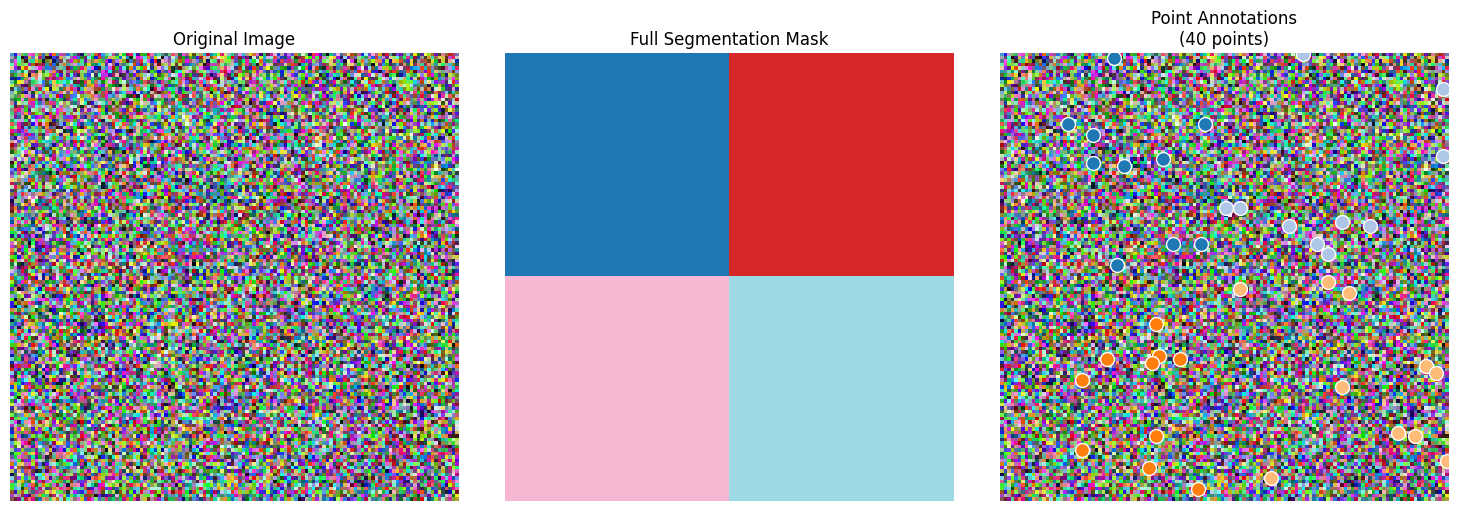

In [3]:
def generate_point_labels(mask, num_points_per_class=5, strategy='random'):
    """
    Generate point annotations from a full segmentation mask.
    
    Args:
        mask: (H, W) - full segmentation mask (numpy array or tf tensor)
        num_points_per_class: Number of points to sample per class
        strategy: 'random', 'grid', 'boundary'
    
    Returns:
        point_mask: (H, W) - mask with -1 for unlabeled, class label for labeled
        label_positions: list of (r, c) tuples of labeled pixel positions
    """
    # Convert to numpy if tensor
    if isinstance(mask, tf.Tensor):
        mask = mask.numpy()
    
    mask = mask.astype(np.int32)
    H, W = mask.shape
    point_mask = np.full((H, W), -1, dtype=np.int32)
    
    unique_classes = np.unique(mask)
    unique_classes = unique_classes[unique_classes >= 0]  # Ignore negative values
    
    label_positions = []
    
    for cls in unique_classes:
        cls_mask = (mask == cls)
        cls_pixels = np.argwhere(cls_mask)
        
        if len(cls_pixels) == 0:
            continue
        
        if strategy == 'random':
            # Random sampling
            num_samples = min(num_points_per_class, len(cls_pixels))
            indices = np.random.choice(len(cls_pixels), num_samples, replace=False)
            selected = cls_pixels[indices]
            
        elif strategy == 'grid':
            # Grid-based sampling
            num_samples = min(num_points_per_class, len(cls_pixels))
            grid_size = int(np.sqrt(num_samples)) + 1
            selected = []
            
            r_min, r_max = cls_pixels[:, 0].min(), cls_pixels[:, 0].max()
            c_min, c_max = cls_pixels[:, 1].min(), cls_pixels[:, 1].max()
            
            for i in range(grid_size):
                for j in range(grid_size):
                    if len(selected) >= num_samples:
                        break
                    # Compute grid position
                    r = int((i * r_max + (grid_size - i) * r_min) / grid_size)
                    c = int((j * c_max + (grid_size - j) * c_min) / grid_size)
                    
                    # Find nearest pixel of this class
                    distances = np.sqrt((cls_pixels[:, 0] - r)**2 + (cls_pixels[:, 1] - c)**2)
                    nearest_idx = np.argmin(distances)
                    nearest = cls_pixels[nearest_idx]
                    
                    # Avoid duplicates
                    if not any(np.array_equal(nearest, s) for s in selected):
                        selected.append(nearest)
            
            selected = np.array(selected) if selected else cls_pixels[:1]
            
        elif strategy == 'boundary':
            # Sample near boundaries (more informative)
            cls_mask_binary = cls_mask.astype(np.uint8)
            eroded = binary_erosion(cls_mask_binary)
            boundary = cls_mask_binary & ~eroded
            boundary_pixels = np.argwhere(boundary)
            
            if len(boundary_pixels) > 0:
                num_samples = min(num_points_per_class, len(boundary_pixels))
                indices = np.random.choice(len(boundary_pixels), num_samples, replace=False)
                selected = boundary_pixels[indices]
            else:
                selected = cls_pixels[:1]
        
        else:
            num_samples = min(num_points_per_class, len(cls_pixels))
            selected = cls_pixels[:num_samples]
        
        for r, c in selected:
            point_mask[r, c] = int(cls)
            label_positions.append((int(r), int(c)))
    
    return point_mask, label_positions


def visualize_point_labels(image, full_mask, point_mask, title="Point Annotations"):
    """Visualize point labels overlay."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Convert tensors if needed
    if isinstance(image, tf.Tensor):
        image = image.numpy()
    if isinstance(full_mask, tf.Tensor):
        full_mask = full_mask.numpy()
    if isinstance(point_mask, tf.Tensor):
        point_mask = point_mask.numpy()
    
    # Original image
    axes[0].imshow(image)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    # Full mask
    axes[1].imshow(full_mask, cmap='tab20')
    axes[1].set_title('Full Segmentation Mask')
    axes[1].axis('off')
    
    # Point annotations
    axes[2].imshow(image)
    labeled_pixels = np.argwhere(point_mask != -1)
    
    colors = plt.cm.tab20(np.linspace(0, 1, 20))
    for r, c in labeled_pixels:
        cls = point_mask[r, c]
        axes[2].scatter(c, r, c=[colors[cls]], s=100, marker='o', edgecolors='white', linewidths=1)
    
    axes[2].set_title(f'{title}\n({len(labeled_pixels)} points)')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()


# Test point label generation
def test_point_generation():
    print("Testing point label generation...")
    
    # Create a synthetic mask
    H, W = 128, 128
    mask = np.zeros((H, W), dtype=np.int32)
    mask[:64, :64] = 0
    mask[:64, 64:] = 1
    mask[64:, :64] = 2
    mask[64:, 64:] = 3
    
    # Generate point labels
    point_mask, positions = generate_point_labels(mask, num_points_per_class=10, strategy='random')
    
    # Create a dummy image
    image = np.random.rand(H, W, 3).clip(0, 1)
    
    visualize_point_labels(image, mask, point_mask)
    
    return point_mask

point_mask = test_point_generation()

## 3. Segmentation Models

Implementing U-Net and DeepLabV3-style architectures using Keras.

In [4]:
def conv_block(x, filters, kernel_size=3, batch_norm=True):
    """Convolution block with optional batch normalization."""
    x = layers.Conv2D(filters, kernel_size, padding='same', use_bias=not batch_norm)(x)
    if batch_norm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x


def double_conv_block(x, filters):
    """Double convolution block: (Conv -> BN -> ReLU) x 2"""
    x = conv_block(x, filters)
    x = conv_block(x, filters)
    return x


def build_unet_lite(input_shape=(256, 256, 3), num_classes=5):
    """
    Build a lightweight U-Net for semantic segmentation.
    
    Args:
        input_shape: (H, W, C) input image shape
        num_classes: Number of segmentation classes
    
    Returns:
        Keras Model
    """
    inputs = layers.Input(shape=input_shape)
    
    # Encoder
    # Level 1
    c1 = double_conv_block(inputs, 32)
    p1 = layers.MaxPooling2D((2, 2))(c1)
    
    # Level 2
    c2 = double_conv_block(p1, 64)
    p2 = layers.MaxPooling2D((2, 2))(c2)
    
    # Level 3
    c3 = double_conv_block(p2, 128)
    p3 = layers.MaxPooling2D((2, 2))(c3)
    
    # Level 4 (bottleneck)
    c4 = double_conv_block(p3, 256)
    
    # Decoder
    # Level 3
    u3 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c4)
    u3 = layers.Concatenate()([u3, c3])
    c5 = double_conv_block(u3, 128)
    
    # Level 2
    u2 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c5)
    u2 = layers.Concatenate()([u2, c2])
    c6 = double_conv_block(u2, 64)
    
    # Level 1
    u1 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c6)
    u1 = layers.Concatenate()([u1, c1])
    c7 = double_conv_block(u1, 32)
    
    # Output (raw logits)
    outputs = layers.Conv2D(num_classes, (1, 1), padding='same')(c7)
    
    model = Model(inputs, outputs, name='UNetLite')
    return model


def aspp_block(x, filters, rates=[6, 12, 18]):
    """
    Atrous Spatial Pyramid Pooling block.
    
    Args:
        x: Input tensor
        filters: Number of output filters
        rates: Dilation rates for ASPP
    """
    # 1x1 convolution
    conv1 = layers.Conv2D(filters, 1, padding='same', use_bias=False)(x)
    conv1 = layers.BatchNormalization()(conv1)
    conv1 = layers.Activation('relu')(conv1)
    
    # Dilated convolutions
    aspp_layers = [conv1]
    for rate in rates:
        conv = layers.Conv2D(filters, 3, padding='same', dilation_rate=rate, use_bias=False)(x)
        conv = layers.BatchNormalization()(conv)
        conv = layers.Activation('relu')(conv)
        aspp_layers.append(conv)
    
    # Global average pooling
    gap = layers.GlobalAveragePooling2D()(x)
    gap = layers.Reshape((1, 1, x.shape[-1]))(gap)
    gap = layers.Conv2D(filters, 1, use_bias=False)(gap)
    gap = layers.BatchNormalization()(gap)
    gap = layers.Activation('relu')(gap)
    gap = layers.UpSampling2D(size=x.shape[1:3], interpolation='bilinear')(gap)
    aspp_layers.append(gap)
    
    # Concatenate all branches
    concat = layers.Concatenate()(aspp_layers)
    
    # Project
    output = layers.Conv2D(filters, 1, padding='same', use_bias=False)(concat)
    output = layers.BatchNormalization()(output)
    output = layers.Activation('relu')(output)
    output = layers.Dropout(0.5)(output)
    
    return output


def build_deeplabv3_lite(input_shape=(256, 256, 3), num_classes=5):
    """
    Build a lightweight DeepLabV3-style model with ASPP.
    
    Args:
        input_shape: (H, W, C) input image shape
        num_classes: Number of segmentation classes
    
    Returns:
        Keras Model
    """
    inputs = layers.Input(shape=input_shape)
    
    # Initial convolution
    x = layers.Conv2D(64, 7, strides=2, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)
    
    # Simplified backbone
    # Block 1
    x = layers.Conv2D(128, 3, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # Block 2
    x = layers.Conv2D(256, 3, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(256, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # Block 3
    x = layers.Conv2D(512, 3, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(512, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # ASPP
    x = aspp_block(x, 256)
    
    # Decoder
    x = layers.Conv2D(256, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Conv2D(num_classes, 1)(x)
    
    # Upsample to input size
    outputs = layers.UpSampling2D(size=input_shape[:2], interpolation='bilinear')(x)
    
    model = Model(inputs, outputs, name='DeepLabV3Lite')
    return model


# Test models
def test_models():
    print("Testing model architectures...")
    
    # Test U-Net
    unet = build_unet_lite(input_shape=(128, 128, 3), num_classes=5)
    x = tf.random.normal([2, 128, 128, 3])
    out = unet(x)
    print(f"\nUNetLite:")
    print(f"  Input shape:  {x.shape}")
    print(f"  Output shape: {out.shape}")
    print(f"  Parameters:   {unet.count_params():,}")
    
    # Test DeepLabV3
    deeplab = build_deeplabv3_lite(input_shape=(128, 128, 3), num_classes=5)
    out2 = deeplab(x)
    print(f"\nDeepLabV3Lite:")
    print(f"  Input shape:  {x.shape}")
    print(f"  Output shape: {out2.shape}")
    print(f"  Parameters:   {deeplab.count_params():,}")
    
    return unet, deeplab

unet_model, deeplab_model = test_models()

Testing model architectures...



UNetLite:
  Input shape:  (2, 128, 128, 3)
  Output shape: (2, 128, 128, 5)
  Parameters:   1,929,957



DeepLabV3Lite:
  Input shape:  (2, 128, 128, 3)
  Output shape: (2, 512, 512, 5)
  Parameters:   9,388,741


## 4. Dataset Pipeline

Using tf.data API for efficient data loading.

Creating datasets...
Train dataset size: 200
Validation dataset size: 50

Visualizing samples:


I0000 00:00:1773601171.754202   15185 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


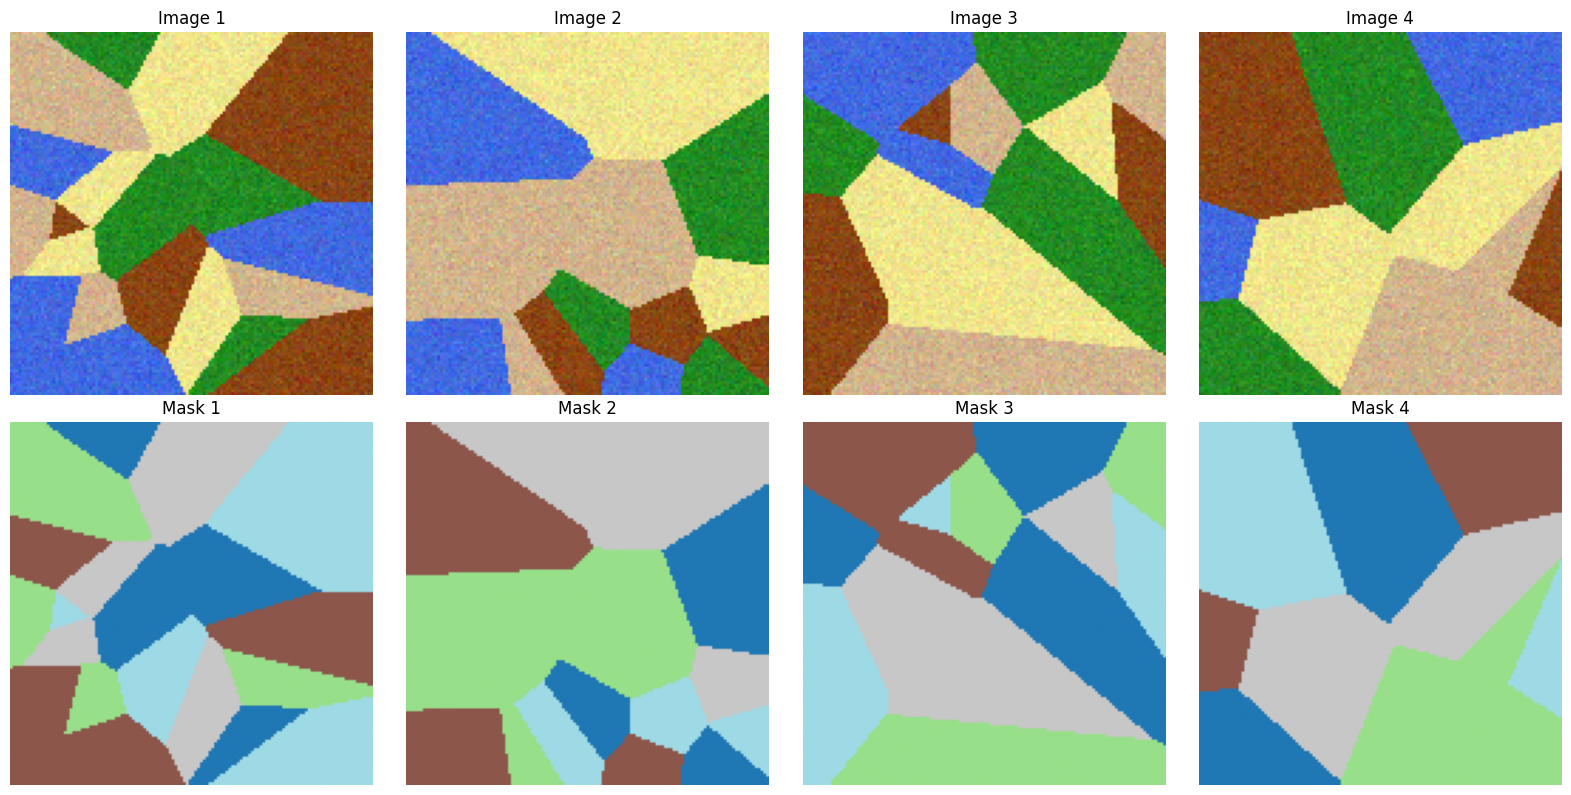

In [5]:
class SyntheticRemoteSensingDataset:
    """
    Synthetic remote sensing dataset for segmentation.
    Generates synthetic images with various land cover types.
    """
    def __init__(self, num_samples=500, img_size=256, num_classes=5):
        self.num_samples = num_samples
        self.img_size = img_size
        self.num_classes = num_classes
        
        # Define color patterns for different classes
        self.class_colors = {
            0: [34, 139, 34],    # Forest - green
            1: [210, 180, 140],  # Urban - tan
            2: [65, 105, 225],   # Water - blue
            3: [240, 230, 140],  # Agricultural - yellow
            4: [139, 69, 19],    # Bare soil - brown
        }
    
    def generate_sample(self):
        """Generate a single synthetic sample."""
        # Generate random seed points for Voronoi regions
        mask = np.zeros((self.img_size, self.img_size), dtype=np.int32)
        
        num_seeds_per_class = random.randint(2, 5)
        seeds = []
        for cls in range(self.num_classes):
            for _ in range(num_seeds_per_class):
                seeds.append({
                    'class': cls,
                    'x': random.randint(0, self.img_size - 1),
                    'y': random.randint(0, self.img_size - 1)
                })
        
        # Assign each pixel to nearest seed (Voronoi)
        seed_coords = np.array([[s['x'], s['y']] for s in seeds])
        seed_classes = np.array([s['class'] for s in seeds])
        
        y_coords, x_coords = np.meshgrid(np.arange(self.img_size), np.arange(self.img_size))
        pixels = np.column_stack([x_coords.ravel(), y_coords.ravel()])
        
        tree = cKDTree(seed_coords)
        _, indices = tree.query(pixels)
        mask = seed_classes[indices].reshape(self.img_size, self.img_size).astype(np.int32)
        
        # Add some smoothness
        for _ in range(2):
            new_mask = mask.copy()
            for i in range(self.img_size):
                for j in range(self.img_size):
                    if random.random() < 0.1:
                        neighbors = []
                        for di in [-1, 0, 1]:
                            for dj in [-1, 0, 1]:
                                ni, nj = i + di, j + dj
                                if 0 <= ni < self.img_size and 0 <= nj < self.img_size:
                                    neighbors.append(mask[ni, nj])
                        if neighbors:
                            new_mask[i, j] = max(set(neighbors), key=neighbors.count)
            mask = new_mask
        
        # Generate image from mask
        image = np.zeros((self.img_size, self.img_size, 3), dtype=np.float32)
        for cls, color in self.class_colors.items():
            for c in range(3):
                base_color = color[c] / 255.0
                noise = np.random.randn(self.img_size, self.img_size) * 0.05
                image[:, :, c] += (mask == cls).astype(np.float32) * (base_color + noise)
        
        image = np.clip(image, 0, 1).astype(np.float32)
        
        # Normalize image
        image = (image - 0.5) / 0.5  # Normalize to [-1, 1]
        
        return image.astype(np.float32), mask.astype(np.int32)


def create_tf_dataset(base_dataset, num_points_per_class=5, point_strategy='random', 
                      batch_size=16, shuffle=True, include_full_mask=True):
    """
    Create a tf.data.Dataset from the synthetic dataset.
    
    Args:
        base_dataset: SyntheticRemoteSensingDataset instance
        num_points_per_class: Number of point labels per class
        point_strategy: Sampling strategy for point labels
        batch_size: Batch size
        shuffle: Whether to shuffle
        include_full_mask: Whether to include full masks (for evaluation)
    
    Returns:
        tf.data.Dataset
    """
    def generator():
        for i in range(base_dataset.num_samples):
            image, full_mask = base_dataset.generate_sample()
            
            # Generate point labels
            point_mask, _ = generate_point_labels(
                full_mask, 
                num_points_per_class=num_points_per_class,
                strategy=point_strategy
            )
            
            if include_full_mask:
                yield image, point_mask.astype(np.int32), full_mask.astype(np.int32)
            else:
                yield image, point_mask.astype(np.int32)
    
    if include_full_mask:
        output_signature = (
            tf.TensorSpec(shape=(base_dataset.img_size, base_dataset.img_size, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(base_dataset.img_size, base_dataset.img_size), dtype=tf.int32),
            tf.TensorSpec(shape=(base_dataset.img_size, base_dataset.img_size), dtype=tf.int32)
        )
    else:
        output_signature = (
            tf.TensorSpec(shape=(base_dataset.img_size, base_dataset.img_size, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(base_dataset.img_size, base_dataset.img_size), dtype=tf.int32)
        )
    
    dataset = tf.data.Dataset.from_generator(generator, output_signature=output_signature)
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=100)
    
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset


def visualize_dataset_samples(dataset, num_samples=4):
    """Visualize samples from the dataset."""
    fig, axes = plt.subplots(2, num_samples, figsize=(4*num_samples, 8))
    
    for i, batch in enumerate(dataset.take(num_samples)):
        if len(batch) == 3:
            image, point_mask, full_mask = batch
        else:
            image, full_mask = batch
            point_mask = None
        
        # Take first sample from batch
        image = image[0].numpy()
        full_mask = full_mask[0].numpy()
        
        # Denormalize for visualization
        image_vis = image * 0.5 + 0.5
        image_vis = np.clip(image_vis, 0, 1)
        
        axes[0, i].imshow(image_vis)
        axes[0, i].set_title(f'Image {i+1}')
        axes[0, i].axis('off')
        
        axes[1, i].imshow(full_mask, cmap='tab20')
        axes[1, i].set_title(f'Mask {i+1}')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()


# Create and visualize datasets
print("Creating datasets...")
train_base = SyntheticRemoteSensingDataset(num_samples=200, img_size=128, num_classes=5)
val_base = SyntheticRemoteSensingDataset(num_samples=50, img_size=128, num_classes=5)

print(f"Train dataset size: {train_base.num_samples}")
print(f"Validation dataset size: {val_base.num_samples}")

print("\nVisualizing samples:")
val_dataset_viz = create_tf_dataset(val_base, num_points_per_class=5, batch_size=4, shuffle=False)
visualize_dataset_samples(val_dataset_viz)

## 5. Custom Training Loop with Metrics

Implementing a custom training loop to handle partial labels and compute metrics.

In [6]:
def compute_iou(y_true, y_pred, num_classes):
    """
    Compute Intersection over Union for each class.
    
    Args:
        y_true: Ground truth labels (B, H, W)
        y_pred: Predicted labels (B, H, W)
        num_classes: Number of classes
    
    Returns:
        iou_per_class: Array of IoU values per class
        mean_iou: Mean IoU across all classes
    """
    iou_per_class = []
    
    for cls in range(num_classes):
        pred_cls = (y_pred == cls)
        true_cls = (y_true == cls)
        
        intersection = np.logical_and(pred_cls, true_cls).sum()
        union = np.logical_or(pred_cls, true_cls).sum()
        
        if union > 0:
            iou = intersection / union
        else:
            iou = 1.0  # Perfect score if both are empty
        
        iou_per_class.append(iou)
    
    return np.array(iou_per_class), np.mean(iou_per_class)


class SegmentationTrainer:
    """
    Custom trainer for segmentation with partial labels.
    """
    def __init__(self, model, num_classes=5, learning_rate=0.001, use_point_labels=True):
        self.model = model
        self.num_classes = num_classes
        self.use_point_labels = use_point_labels
        
        # Loss function
        if use_point_labels:
            self.loss_fn = PartialCrossEntropyLoss(ignore_index=-1)
        else:
            self.loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
        
        # Optimizer
        self.optimizer = optimizers.Adam(learning_rate=learning_rate)
    
    def train_step(self, batch):
        """Single training step."""
        if self.use_point_labels:
            images, point_masks, _ = batch
            targets = point_masks
        else:
            images, full_masks = batch[0], batch[-1]
            targets = full_masks
        
        with tf.GradientTape() as tape:
            predictions = self.model(images, training=True)
            loss = self.loss_fn(targets, predictions)
        
        gradients = tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.model.trainable_variables))
        
        return loss
    
    def validate(self, dataset, full_loss_fn=None):
        """
        Validate on full masks (for fair evaluation).
        
        Returns:
            Dictionary with metrics
        """
        if full_loss_fn is None:
            full_loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
        
        total_loss = 0.0
        total_correct = 0
        total_pixels = 0
        all_ious = []
        batch_count = 0
        
        for batch in dataset:
            # Get full masks for evaluation
            images = batch[0]
            full_masks = batch[-1]
            
            predictions = self.model(images, training=False)
            
            # Compute loss on full mask
            loss = full_loss_fn(full_masks, predictions)
            total_loss += loss.numpy()
            batch_count += 1
            
            # Get predictions
            preds = tf.argmax(predictions, axis=-1).numpy()
            masks = full_masks.numpy()
            
            # Pixel accuracy
            total_correct += (preds == masks).sum()
            total_pixels += masks.size
            
            # IoU per batch
            for i in range(len(preds)):
                _, miou = compute_iou(masks[i], preds[i], self.num_classes)
                all_ious.append(miou)
        
        avg_loss = total_loss / max(batch_count, 1)
        pixel_accuracy = total_correct / max(total_pixels, 1)
        mean_iou = np.mean(all_ious) if all_ious else 0.0
        
        return {
            'loss': avg_loss,
            'pixel_accuracy': pixel_accuracy,
            'miou': mean_iou
        }
    
    def fit(self, train_dataset, val_dataset, epochs=10, verbose=True):
        """
        Train the model.
        
        Returns:
            Training history dictionary
        """
        history = {
            'train_loss': [],
            'val_loss': [],
            'val_miou': [],
            'val_acc': []
        }
        
        best_miou = 0.0
        best_weights = None
        
        for epoch in range(epochs):
            # Training
            epoch_losses = []
            for batch in tqdm(train_dataset, desc=f'Epoch {epoch+1}/{epochs}', 
                             disable=not verbose):
                loss = self.train_step(batch)
                epoch_losses.append(loss.numpy())
            
            train_loss = np.mean(epoch_losses)
            
            # Validation
            val_metrics = self.validate(val_dataset)
            
            # Record history
            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_metrics['loss'])
            history['val_miou'].append(val_metrics['miou'])
            history['val_acc'].append(val_metrics['pixel_accuracy'])
            
            # Save best model
            if val_metrics['miou'] > best_miou:
                best_miou = val_metrics['miou']
                best_weights = self.model.get_weights()
            
            if verbose:
                print(f"Epoch {epoch+1}/{epochs} - "
                      f"Train Loss: {train_loss:.4f}, "
                      f"Val Loss: {val_metrics['loss']:.4f}, "
                      f"Val mIoU: {val_metrics['miou']:.4f}, "
                      f"Val Acc: {val_metrics['pixel_accuracy']:.4f}")
        
        # Restore best weights
        if best_weights is not None:
            self.model.set_weights(best_weights)
        
        return history, best_miou

## 6. Experiments

In [7]:
def plot_training_history(histories, labels, metric='val_miou'):
    """Plot training history comparing different runs."""
    plt.figure(figsize=(10, 6))
    
    for history, label in zip(histories, labels):
        epochs = range(1, len(history[metric]) + 1)
        plt.plot(epochs, history[metric], marker='o', label=label, linewidth=2)
    
    plt.xlabel('Epoch')
    plt.ylabel('Validation mIoU' if metric == 'val_miou' else metric)
    plt.title('Training Progress Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def visualize_predictions(model, dataset, num_samples=3):
    """Visualize model predictions on validation samples."""
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))
    
    sample_count = 0
    for batch in dataset:
        if sample_count >= num_samples:
            break
        
        images = batch[0]
        point_masks = batch[1]
        full_masks = batch[2]
        
        # Get predictions
        predictions = model(images, training=False)
        preds = tf.argmax(predictions, axis=-1).numpy()
        
        for i in range(len(images)):
            if sample_count >= num_samples:
                break
            
            # Denormalize image
            image_vis = images[i].numpy() * 0.5 + 0.5
            image_vis = np.clip(image_vis, 0, 1)
            
            point_mask = point_masks[i].numpy()
            full_mask = full_masks[i].numpy()
            pred = preds[i]
            
            # Plot
            axes[sample_count, 0].imshow(image_vis)
            axes[sample_count, 0].set_title('Image')
            axes[sample_count, 0].axis('off')
            
            # Point labels with markers
            axes[sample_count, 1].imshow(image_vis)
            labeled_pixels = np.argwhere(point_mask != -1)
            colors = plt.cm.tab20(np.linspace(0, 1, 20))
            for r, c in labeled_pixels:
                cls = point_mask[r, c]
                axes[sample_count, 1].scatter(c, r, c=[colors[cls]], s=50, marker='o', 
                                              edgecolors='white', linewidths=1)
            axes[sample_count, 1].set_title('Point Labels')
            axes[sample_count, 1].axis('off')
            
            axes[sample_count, 2].imshow(full_mask, cmap='tab20')
            axes[sample_count, 2].set_title('Ground Truth')
            axes[sample_count, 2].axis('off')
            
            axes[sample_count, 3].imshow(pred, cmap='tab20')
            axes[sample_count, 3].set_title('Prediction')
            axes[sample_count, 3].axis('off')
            
            sample_count += 1
    
    plt.tight_layout()
    plt.show()

### Experiment 1: Point vs. Full Supervision Comparison

EXPERIMENT: Point vs. Full Supervision Comparison

--- Point Supervision (5 points per class) ---


Epoch 1/5: 0it [00:00, ?it/s]

Epoch 1/5: 1it [00:01,  1.53s/it]

Epoch 1/5: 2it [00:02,  1.04s/it]

Epoch 1/5: 3it [00:02,  1.14it/s]

...

Epoch 5/5: 2it [00:01,  1.19it/s]

Epoch 5/5: 3it [00:02,  1.30it/s]

Epoch 5/5: 4it [00:02,  1.68it/s]

Epoch 5/5: 4it [00:02,  1.45it/s]

Epoch 5/5 - Train Loss: 0.2460, Val Loss: 1.1671, Val mIoU: 0.6640, Val Acc: 0.7775

SUMMARY
Point Supervision (5 pts/class) - Best mIoU: 0.6601
Full Supervision - Best mIoU: 0.6640

Performance Gap: 0.0039
Relative Performance: 99.4%


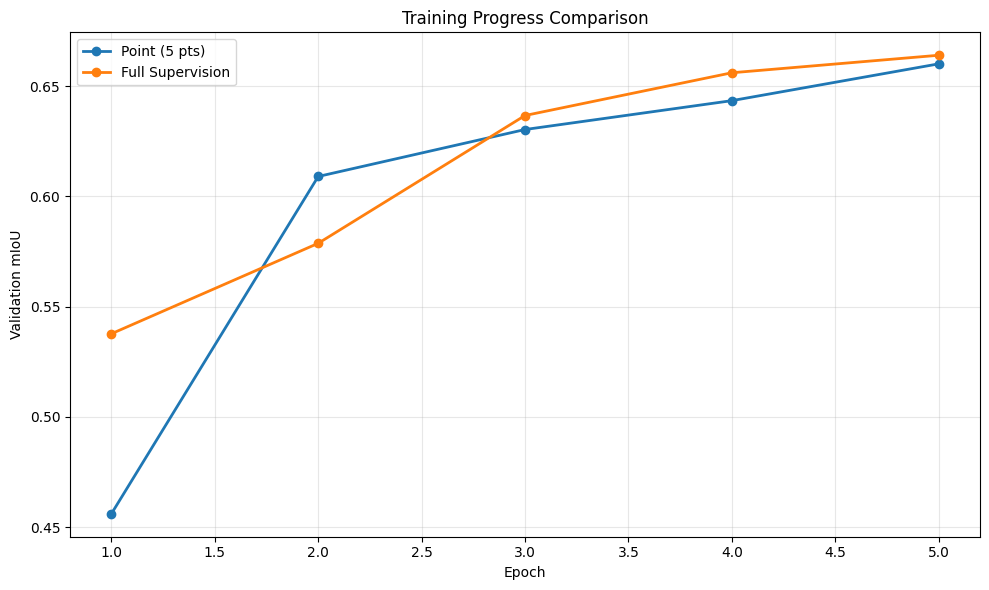


Point Supervision Predictions:


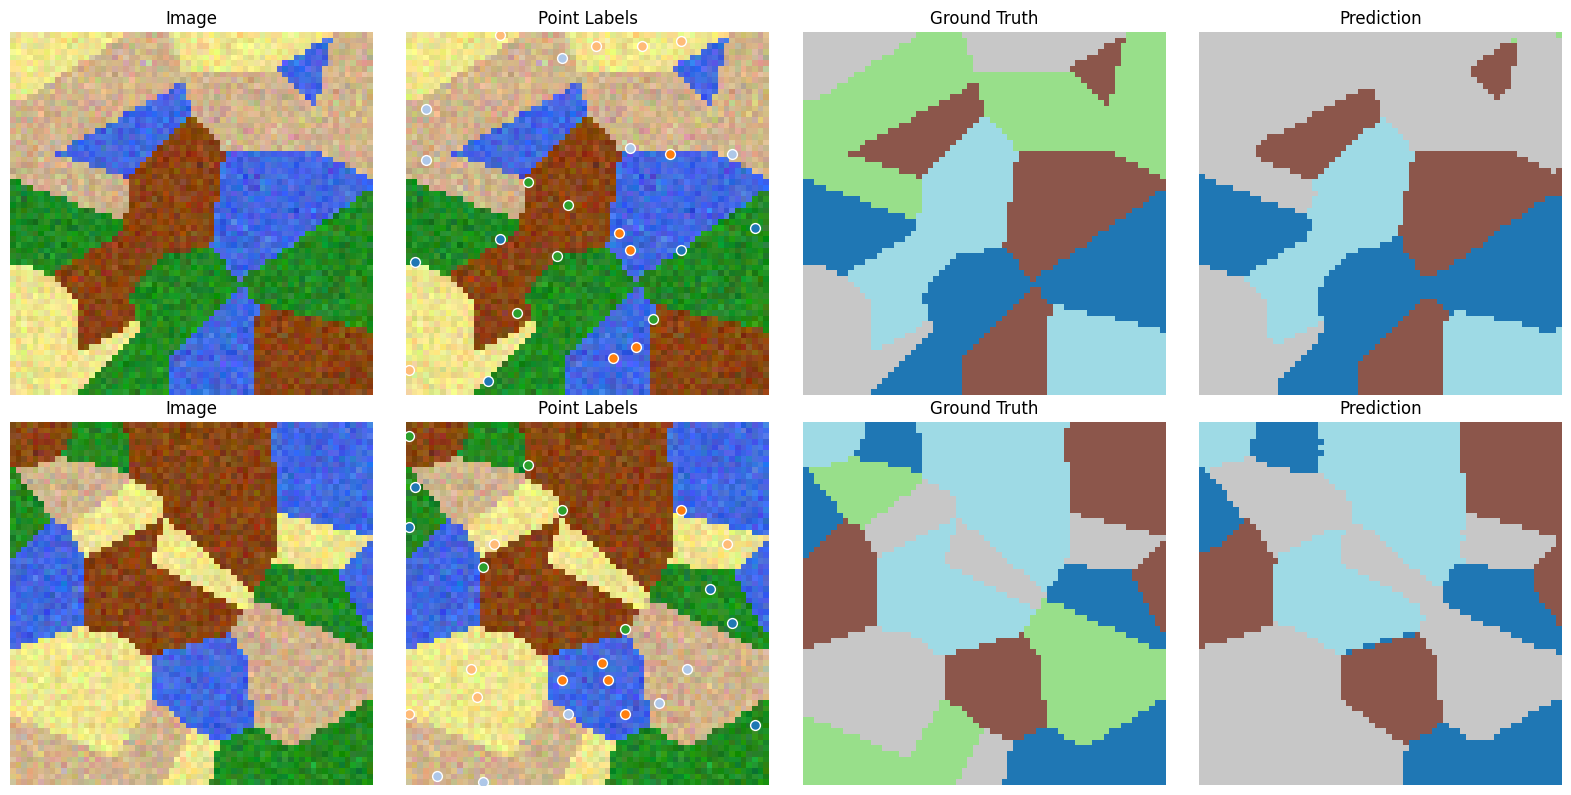


Full Supervision Predictions:


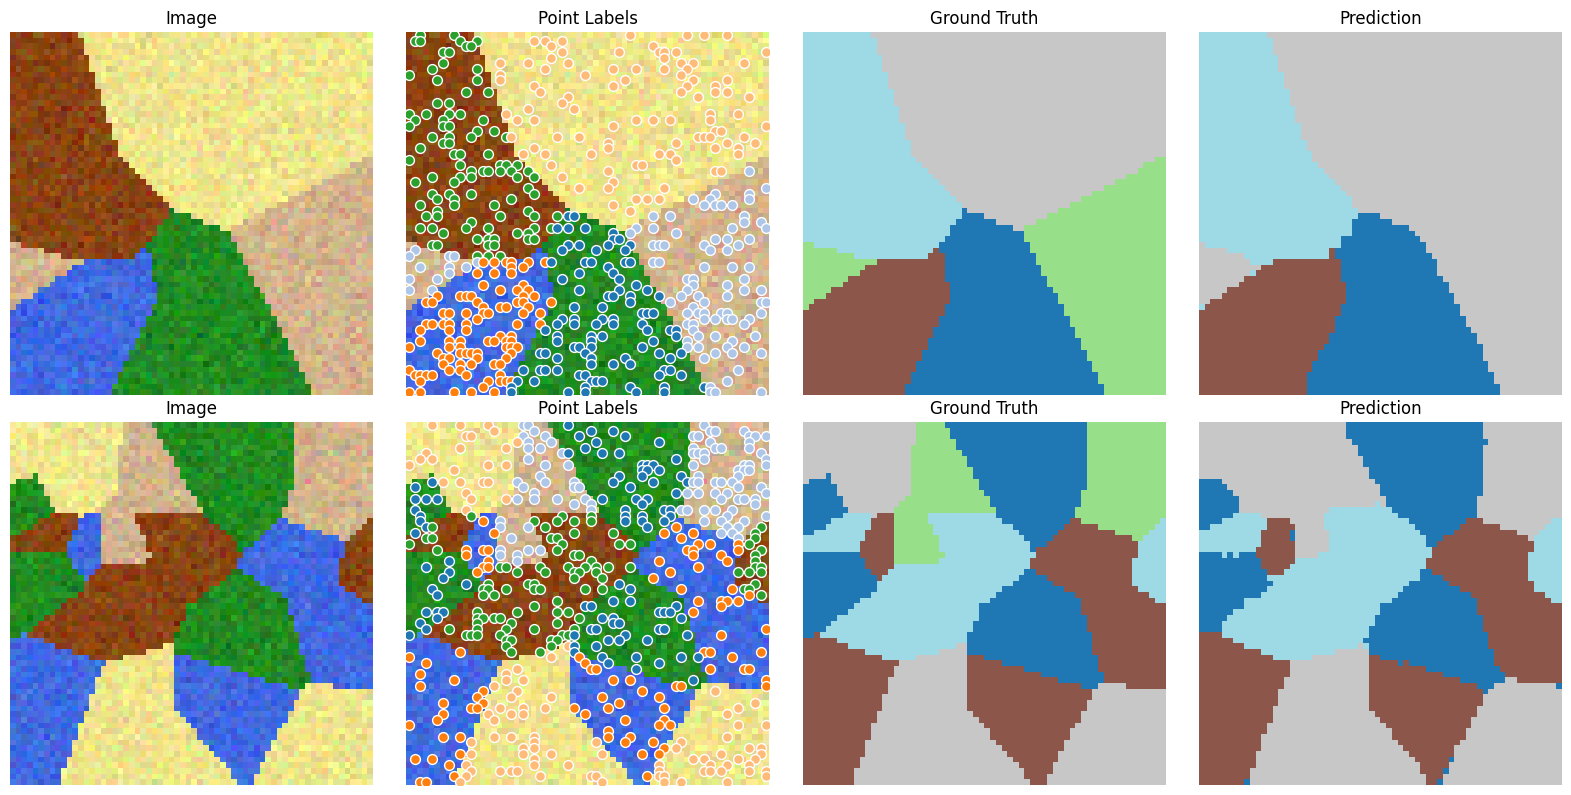

In [8]:
def experiment_supervision_comparison():
    """
    Compare partial CE loss (point supervision) vs. full supervision.
    Quick version with fewer epochs and samples.
    """
    print("="*60)
    print("EXPERIMENT: Point vs. Full Supervision Comparison")
    print("="*60)
    
    # Parameters (reduced for quick demo)
    num_epochs = 5
    batch_size = 16
    learning_rate = 0.001
    img_size = 64  # Smaller images for faster training
    num_classes = 5
    num_points = 5
    num_train = 50  # Fewer samples
    num_val = 10
    
    results = {}
    
    # ===== Point Supervision =====
    print(f"\n--- Point Supervision ({num_points} points per class) ---")
    
    train_base_p = SyntheticRemoteSensingDataset(num_samples=num_train, img_size=img_size)
    val_base_p = SyntheticRemoteSensingDataset(num_samples=num_val, img_size=img_size)
    
    train_dataset_p = create_tf_dataset(train_base_p, num_points_per_class=num_points, 
                                        batch_size=batch_size, shuffle=True)
    val_dataset_p = create_tf_dataset(val_base_p, num_points_per_class=num_points,
                                      batch_size=batch_size, shuffle=False)
    
    model_point = build_unet_lite(input_shape=(img_size, img_size, 3), num_classes=num_classes)
    trainer_point = SegmentationTrainer(model_point, num_classes=num_classes, 
                                        learning_rate=learning_rate, use_point_labels=True)
    
    history_point, best_miou_point = trainer_point.fit(
        train_dataset_p, val_dataset_p, epochs=num_epochs
    )
    
    results['point'] = {
        'history': history_point,
        'best_miou': best_miou_point
    }
    
    # ===== Full Supervision =====
    print(f"\n--- Full Supervision ---")
    
    train_base_f = SyntheticRemoteSensingDataset(num_samples=num_train, img_size=img_size)
    val_base_f = SyntheticRemoteSensingDataset(num_samples=num_val, img_size=img_size)
    
    train_dataset_f = create_tf_dataset(train_base_f, num_points_per_class=100,
                                        batch_size=batch_size, shuffle=True)
    val_dataset_f = create_tf_dataset(val_base_f, num_points_per_class=100,
                                      batch_size=batch_size, shuffle=False)
    
    model_full = build_unet_lite(input_shape=(img_size, img_size, 3), num_classes=num_classes)
    trainer_full = SegmentationTrainer(model_full, num_classes=num_classes,
                                       learning_rate=learning_rate, use_point_labels=False)
    
    history_full, best_miou_full = trainer_full.fit(
        train_dataset_f, val_dataset_f, epochs=num_epochs
    )
    
    results['full'] = {
        'history': history_full,
        'best_miou': best_miou_full
    }
    
    # Summary
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"Point Supervision ({num_points} pts/class) - Best mIoU: {results['point']['best_miou']:.4f}")
    print(f"Full Supervision - Best mIoU: {results['full']['best_miou']:.4f}")
    print(f"\nPerformance Gap: {results['full']['best_miou'] - results['point']['best_miou']:.4f}")
    print(f"Relative Performance: {results['point']['best_miou'] / results['full']['best_miou'] * 100:.1f}%")
    print("="*60)
    
    # Plot comparison
    plot_training_history(
        [history_point, history_full],
        [f'Point ({num_points} pts)', 'Full Supervision'],
        metric='val_miou'
    )
    
    # Visualize predictions
    print("\nPoint Supervision Predictions:")
    visualize_predictions(model_point, val_dataset_p, num_samples=2)
    
    print("\nFull Supervision Predictions:")
    visualize_predictions(model_full, val_dataset_f, num_samples=2)
    
    return results

# Run the experiment
results = experiment_supervision_comparison()

### Experiment 2: Effect of Point Annotation Density

In [9]:
def experiment_point_density():
    """
    Experiment: How does the number of point annotations per class affect performance?
    """
    print("="*60)
    print("EXPERIMENT: Effect of Point Annotation Density")
    print("="*60)
    
    # Parameters
    points_per_class_list = [1, 3, 5, 10, 20]
    num_epochs = 10
    batch_size = 16
    learning_rate = 0.001
    img_size = 128
    num_classes = 5
    
    results = []
    
    for num_points in points_per_class_list:
        print(f"\n--- Training with {num_points} points per class ---")
        
        # Create datasets
        train_base = SyntheticRemoteSensingDataset(num_samples=150, img_size=img_size)
        val_base = SyntheticRemoteSensingDataset(num_samples=30, img_size=img_size)
        
        train_dataset = create_tf_dataset(train_base, num_points_per_class=num_points,
                                          batch_size=batch_size, shuffle=True)
        val_dataset = create_tf_dataset(val_base, num_points_per_class=num_points,
                                        batch_size=batch_size, shuffle=False)
        
        # Create model
        model = build_unet_lite(input_shape=(img_size, img_size, 3), num_classes=num_classes)
        trainer = SegmentationTrainer(model, num_classes=num_classes,
                                      learning_rate=learning_rate, use_point_labels=True)
        
        # Train
        history, best_miou = trainer.fit(train_dataset, val_dataset, epochs=num_epochs)
        
        results.append({
            'num_points': num_points,
            'miou': best_miou,
            'history': history
        })
    
    # Plot results
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    x_values = [r['num_points'] for r in results]
    mious = [r['miou'] for r in results]
    
    axes[0].plot(x_values, mious, marker='o', linewidth=2, markersize=10)
    axes[0].set_xlabel('Points per Class')
    axes[0].set_ylabel('Best mIoU')
    axes[0].set_title('Performance vs Point Density')
    axes[0].grid(True, alpha=0.3)
    
    # Plot training curves
    for result in results:
        axes[1].plot(result['history']['val_miou'], 
                     label=f"{result['num_points']} pts", linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Validation mIoU')
    axes[1].set_title('Training Curves by Point Density')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary table
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"{'Points/Class':<15} {'Best mIoU':<15}")
    print("-"*30)
    for r in results:
        print(f"{r['num_points']:<15} {r['miou']:.4f}")
    print("="*60)
    
    return results

# Uncomment to run:
# results_density = experiment_point_density()

## 7. Quick Demo

PARTIAL CE LOSS DEMO (TensorFlow)
\nCreating synthetic datasets (img_size=64)...
Train samples: 50, Val samples: 10
Points per class: 5


Labeled pixel ratio: 0.61%
\nBuilding U-Net Lite model...
Model parameters: 1,929,957
\nTraining with Partial CE Loss...


Epoch 1/5: 0it [00:00, ?it/s]

Epoch 1/5: 1it [00:01,  1.07s/it]

Epoch 1/5: 2it [00:01,  1.28it/s]

...

Epoch 5/5: 6it [00:03,  2.07it/s]

Epoch 5/5: 7it [00:03,  2.35it/s]

Epoch 5/5: 7it [00:03,  2.04it/s]

Epoch 5/5 - Train Loss: 0.1928, Val Loss: 1.0061, Val mIoU: 0.6354, Val Acc: 0.7608


\n============================================================
FINAL RESULTS
Validation Loss:   0.9767
Pixel Accuracy:    0.7655
Best Mean IoU:     0.6354


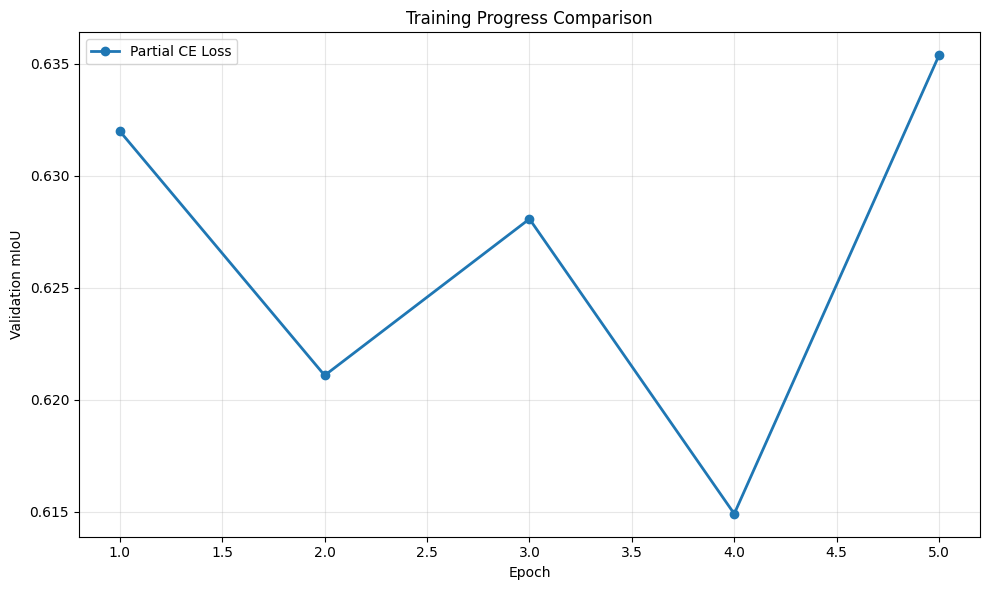

\nVisualizing predictions...


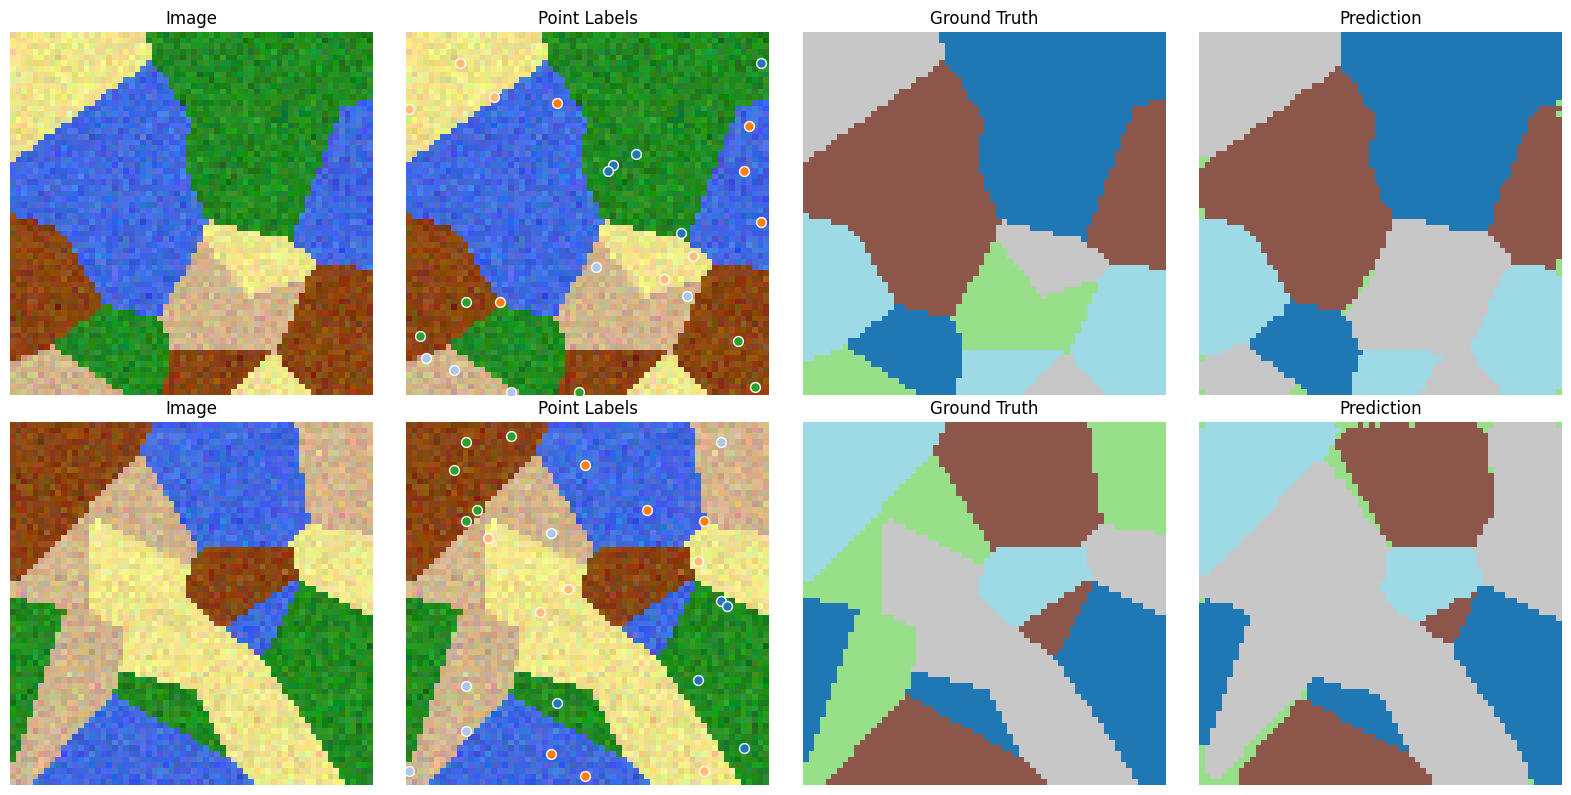

In [10]:
def run_demo():
    """
    Quick demo showing the partial CE loss in action.
    """
    print("="*60)
    print("PARTIAL CE LOSS DEMO (TensorFlow)")
    print("="*60)
    
    # Parameters (reduced for faster demo)
    img_size = 64
    num_classes = 5
    num_points = 5
    num_epochs = 5
    batch_size = 8
    
    print(f"\\nCreating synthetic datasets (img_size={img_size})...")
    train_base = SyntheticRemoteSensingDataset(num_samples=50, img_size=img_size)
    val_base = SyntheticRemoteSensingDataset(num_samples=10, img_size=img_size)
    
    train_dataset = create_tf_dataset(train_base, num_points_per_class=num_points,
                                      batch_size=batch_size, shuffle=True)
    val_dataset = create_tf_dataset(val_base, num_points_per_class=num_points,
                                    batch_size=batch_size, shuffle=False)
    
    print(f"Train samples: {train_base.num_samples}, Val samples: {val_base.num_samples}")
    print(f"Points per class: {num_points}")
    
    # Calculate labeled ratio
    sample_batch = next(iter(train_dataset))
    point_mask = sample_batch[1][0].numpy()
    labeled_ratio = (point_mask != -1).sum() / point_mask.size
    print(f"Labeled pixel ratio: {labeled_ratio*100:.2f}%")
    
    # Build model
    print("\\nBuilding U-Net Lite model...")
    model = build_unet_lite(input_shape=(img_size, img_size, 3), num_classes=num_classes)
    print(f"Model parameters: {model.count_params():,}")
    
    # Train
    print("\\nTraining with Partial CE Loss...")
    trainer = SegmentationTrainer(model, num_classes=num_classes,
                                  learning_rate=0.001, use_point_labels=True)
    
    history, best_miou = trainer.fit(train_dataset, val_dataset, epochs=num_epochs)
    
    # Final evaluation
    final_metrics = trainer.validate(val_dataset)
    
    print("\\n" + "="*60)
    print("FINAL RESULTS")
    print("="*60)
    print(f"Validation Loss:   {final_metrics['loss']:.4f}")
    print(f"Pixel Accuracy:    {final_metrics['pixel_accuracy']:.4f}")
    print(f"Best Mean IoU:     {best_miou:.4f}")
    print("="*60)
    
    # Plot training history
    plot_training_history([history], ['Partial CE Loss'], metric='val_miou')
    
    # Visualize predictions
    print("\\nVisualizing predictions...")
    visualize_predictions(model, val_dataset, num_samples=2)
    
    return model, history

# Run the demo
model, history = run_demo()

## 8. Summary

This notebook demonstrated:

1. **PartialCrossEntropyLoss** - A custom Keras loss that only computes loss on labeled pixels
2. **Point Label Generation** - Converting full masks to sparse annotations
3. **UNetLite & DeepLabV3Lite** - Lightweight segmentation models in Keras
4. **tf.data Pipeline** - Efficient data loading with on-the-fly point generation
5. **Custom Training Loop** - SegmentationTrainer class with metrics tracking

### Key Differences from PyTorch Version:

| Aspect | PyTorch | TensorFlow |
|--------|---------|------------|
| Loss Function | `nn.Module` | `keras.losses.Loss` |
| Model | `nn.Module` | `tf.keras.Model` (Functional API) |
| Data Loading | `DataLoader` + `Dataset` | `tf.data.Dataset` |
| Training | Manual loop | Custom trainer class |
| Device | `.to(device)` | Automatic GPU detection |